# Imports

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn as sns

sns.set_theme()

# Pre-Processing

In [62]:
df = sns.load_dataset('titanic')[["age", "fare", "survived"]]
df = df.dropna(how="any")
df

,age,fare,survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0
...,...,...,...
885,39.0,29.1250,0
886,27.0,13.0000,0
887,19.0,30.0000,1
889,26.0,30.0000,1


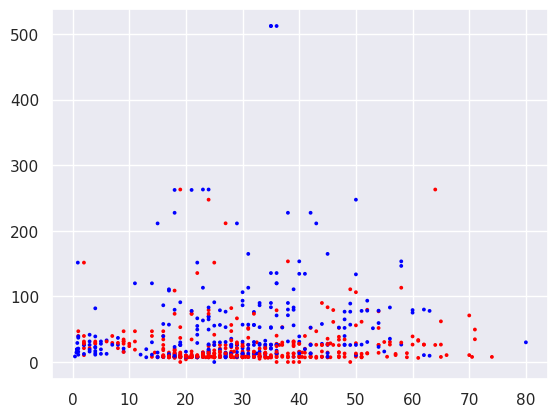

In [ ]:
colors = ["Blue" if x == 1 else "Red" for x in df["survived"]]

plt.scatter(df["age"], df["fare"], c=colors, s = 3)
plt.show()

In [64]:
X = df[['age', 'fare']].to_numpy()
y = np.array([-1 if x == 0 else 1 for x in df['survived']])
X

array([[22.    ,  7.25  ],
       [38.    , 71.2833],
       [26.    ,  7.925 ],
       ...,
       [19.    , 30.    ],
       [26.    , 30.    ],
       [32.    ,  7.75  ]], shape=(714, 2))

In [127]:
def display_classification_line(weights, X, y, bias):
    t = np.linspace(min(X[:, 0]), max(X[:, 0]), 1000)
    y_t = (-weights[0]*t-bias)/weights[1]
    colors = ["Blue" if x == 1 else "Red" for x in y]
    plt.plot(t, y_t)
    plt.scatter(X[:, 0], X[:, 1], c = colors, s = 3)
    plt.show()

In [128]:
class Perceptron():
    def __init__(self, _X):
        self.X = _X
        self.dim = np.shape(self.X)[1]
        self.num_elements = np.shape(self.X)[0]
        self.weights = np.random.rand(self.dim, 1)
        self.bias = np.random.rand(1)[0]

    def error(self, y_diff):
        return 1/4 * sum((y_diff[i])**2 for i in range(len(y_diff)))
    
    def predict(self, X):
        z = (self.weights.T @ X.T + self.bias)
        a = np.where(z < 0, -1, z)
        a = np.where(z >= 0, 1, a)
        return a[0]
    
    def update(self, y_diff, eta):
        for i in range(self.num_elements):
            self.weights += -eta * y_diff[i] * self.X[i:i+1, :].T
            self.bias += -eta * y_diff[i]

    def train(self, y_exact, eta = 1/2, epochs = 100):
        errors = []
        for _ in range(epochs):
            y_calc = self.predict(X)
            y_diff = y_calc - y_exact
            errors.append(self.error(y_diff))
            self.update(y_diff, eta)
        return errors

In [147]:
perc = Perceptron(X)
errors = perc.train(y, eta = 1/2)

Percent correctly classified:

In [148]:
print(str(round((len(X)-errors[-1]) / len(X) * 100, ndigits=2)) + "%")
print(str(int(len(X)-errors[-1])), "correctly classified out of", str(len(X)))

67.51%
482 correctly classified out of 714


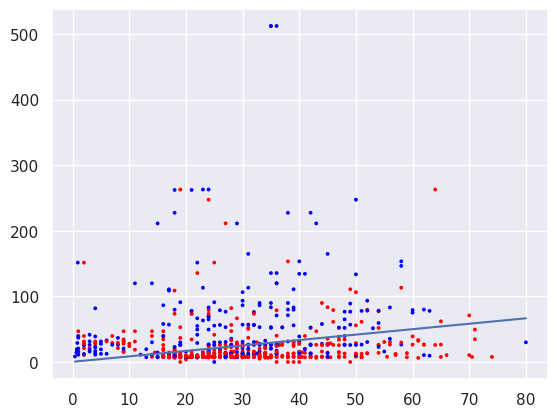

In [149]:
display_classification_line(perc.weights, X, y, perc.bias)

Error over time

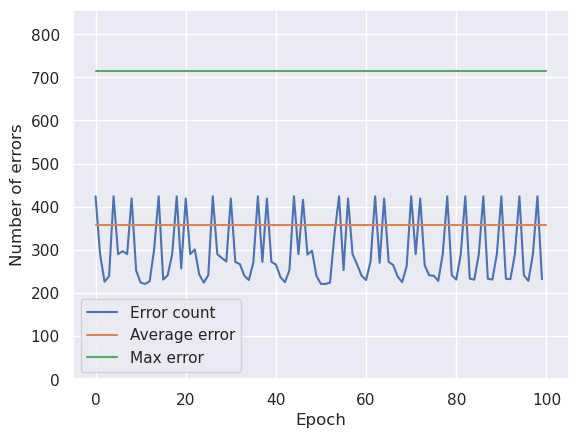

In [150]:
plt.ylim((0.0, len(X)*1.2))
plt.ylabel("Number of errors")
plt.xlabel("Epoch")
plt.plot(errors, label="Error count")
t = np.linspace(0, len(errors), 1000)
plt.plot(t, [len(X)/2 for ti in t], label="Average error")
plt.plot(t, [len(X) for ti in t], label="Max error")
plt.legend()
plt.show()
